# SW and W Distance Data from Result Excel

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ===================== Core Config =====================
dataset_name = "HELOC"
data_dir = f"./{dataset_name}"

file_config_list = [
    {
        "short_name": "DCE",  
        "name": "Raw_DCE",
        "filename_suffix": "_DCE.xlsx",
        "sheet_name": "DCE_Metrics_Summary",
        "sw_col": "X_SWD",
        "w_col": "Y_WD"
    },
    {
        "short_name": "Mean",  
        "name": "Mean_Constrained",
        "filename_suffix": "_MeanConstraint.xlsx",
        "sheet_name": "Mean_Metrics_Summary",
        "sw_col": "X_SWD_mean",
        "w_col": "Y_WD_mean"
    },
    {
        "short_name": "Std",  
        "name": "Std_Constrained",
        "filename_suffix": "_StdConstraint.xlsx",
        "sheet_name": "Std_Metrics_Summary",
        "sw_col": "X_SWD_std",
        "w_col": "Y_WD_std"
    },
    {
        "short_name": "LSC",  
        "name": "LSC_Constrained",
        "filename_suffix": "_LSCConstraint.xlsx",
        "sheet_name": "LSC_Constraint_Metrics_Summary",
        "sw_col": "X_SWD_lsc_constraint",
        "w_col": "Y_WD_lsc_constraint"
    },
    {
        "short_name": "FSD",  
        "name": "FSD_Constrained",
        "filename_suffix": "_FSDConstraint_NetFractionInstallBurden_0.005.xlsx",
        "sheet_name": "FSD_Constraint_Metrics_Summary",
        "sw_col": "X_SWD_fsd_constraint",
        "w_col": "Y_WD_fsd_constraint"
    }
]

sww_stats = {}
for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")
    
    sw_mean = df[config["sw_col"]].mean()
    sw_std = df[config["sw_col"]].std()
    w_mean = df[config["w_col"]].mean()
    w_std = df[config["w_col"]].std()
    
    sww_stats[config["short_name"]] = {
        "SW_Mean": round(sw_mean, 6),
        "SW_Std": round(sw_std, 6),
        "W_Mean": round(w_mean, 6),
        "W_Std": round(w_std, 6)
    }

sww_stats_df = pd.DataFrame(sww_stats).T
print("=== SW/W Mean & Std Results ===")
print(sww_stats_df)


=== SW/W Mean & Std Results ===
       SW_Mean    SW_Std    W_Mean     W_Std
DCE   0.149751  0.009811  0.049109  0.001818
Mean  0.092209  0.004404  0.024585  0.001796
Std   0.086141  0.003102  0.024093  0.001429
LSC   0.090476  0.003351  0.025071  0.001960
FSD   0.094303  0.007050  0.024309  0.001406


In [2]:
plot_rows = []

for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")

    sw_vals = df[config["sw_col"]].dropna().reset_index(drop=True)
    w_vals = df[config["w_col"]].dropna().reset_index(drop=True)

    n = min(len(sw_vals), len(w_vals))

    for i in range(n):
        plot_rows.append({
            "constraint": config["short_name"],
            "run": i + 1,
            "SWD": sw_vals.iloc[i],
            "WD": w_vals.iloc[i]
        })

plot_df = pd.DataFrame(plot_rows)

print("=== Plot-ready data ===")
print(plot_df)

=== Plot-ready data ===
   constraint  run       SWD        WD
0         DCE    1  0.144136  0.048623
1         DCE    2  0.164531  0.048729
2         DCE    3  0.144029  0.046996
3         DCE    4  0.154969  0.052001
4         DCE    5  0.141088  0.049195
5        Mean    1  0.090753  0.023559
6        Mean    2  0.093717  0.024098
7        Mean    3  0.085533  0.023571
8        Mean    4  0.097351  0.023928
9        Mean    5  0.093689  0.027771
10        Std    1  0.090212  0.026386
11        Std    2  0.084453  0.023640
12        Std    3  0.085411  0.024466
13        Std    4  0.082385  0.022740
14        Std    5  0.088244  0.023234
15        LSC    1  0.095010  0.024053
16        LSC    2  0.091073  0.023672
17        LSC    3  0.089504  0.024334
18        LSC    4  0.085713  0.028500
19        LSC    5  0.091079  0.024795
20        FSD    1  0.097373  0.023223
21        FSD    2  0.104460  0.023689
22        FSD    3  0.087078  0.023813
23        FSD    4  0.088475  0.024057
2

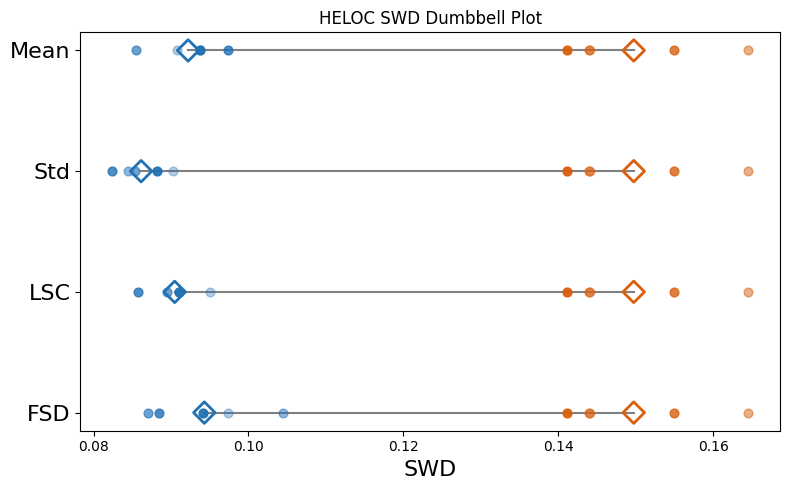

In [3]:
import matplotlib.pyplot as plt
import numpy as np

metric = "SWD"   

constraints = ["Mean", "Std", "LSC", "FSD"]
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    # baseline 
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i,
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    # constrained 
    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i,
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint")
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

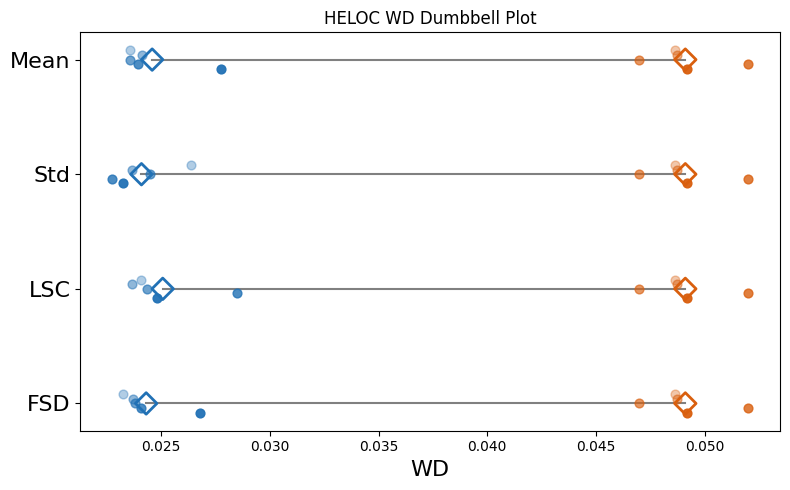

In [4]:
import matplotlib.pyplot as plt
import numpy as np

metric = "WD"   

constraints = ["Mean", "Std", "LSC", "FSD"]
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    offsets = np.array([-0.08, -0.04, 0.0, 0.04, 0.08])
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()   

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint",fontsize=16)
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

# mean

In [5]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    AverageMInFile_col = next(col for col in df.columns if "AverageMInFile" in col)
    AverageMInFile_mean = round(df[AverageMInFile_col].mean(), 6)
    result_list.append([sheet, AverageMInFile_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "AverageMInFile_Mean"])
print(result_df)

overall_mean = round(result_df["AverageMInFile_Mean"].mean(), 6)
overall_std = round(result_df["AverageMInFile_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 AverageMInFile Means: {overall_mean}")
print(f"Std of 5 AverageMInFile Means: {overall_std}")

=== Result DataFrame ===
    Sheet_Name  AverageMInFile_Mean
0  DCE_Seed_40            87.554977
1  DCE_Seed_41            87.435767
2  DCE_Seed_42            87.544113
3  DCE_Seed_43            87.633086
4  DCE_Seed_44            87.636096

=== Overall Statistics ===
Mean of 5 AverageMInFile Means: 87.560808
Std of 5 AverageMInFile Means: 0.081915


In [6]:
baseline_means = result_df["AverageMInFile_Mean"].tolist()
baseline_overall_mean = overall_mean

In [7]:
file_path = os.path.join(data_dir, f"{dataset_name}_MeanConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    AverageMInFile_col = next(col for col in df.columns if "AverageMInFile" in col)
    AverageMInFile_mean = round(df[AverageMInFile_col].mean(), 6)
    result_list.append([sheet, AverageMInFile_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "AverageMInFile_Mean"])
print(result_df)

overall_mean = round(result_df["AverageMInFile_Mean"].mean(), 6)
overall_std = round(result_df["AverageMInFile_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 AverageMInFile Means: {overall_mean}")
print(f"Std of 5 AverageMInFile Means: {overall_std}")

=== Result DataFrame ===
     Sheet_Name  AverageMInFile_Mean
0  Mean_Seed_40            80.094626
1  Mean_Seed_41            80.316648
2  Mean_Seed_42            80.150018
3  Mean_Seed_43            80.526600
4  Mean_Seed_44            80.080438

=== Overall Statistics ===
Mean of 5 AverageMInFile Means: 80.233666
Std of 5 AverageMInFile Means: 0.188749


In [8]:
meanconstraint_means = result_df["AverageMInFile_Mean"].tolist()
meanconstraint_overall_mean = overall_mean

[87.554977, 87.435767, 87.544113, 87.633086, 87.636096]
[80.094626, 80.316648, 80.150018, 80.5266, 80.080438]
80.233666


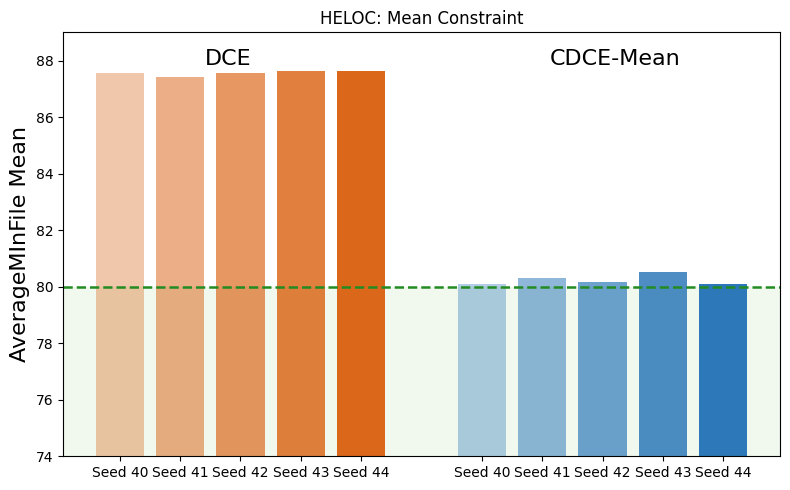

In [9]:
print(baseline_means)
print(meanconstraint_means)
t = np.mean(meanconstraint_means)
print(t)

x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_means):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(meanconstraint_means):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_upper = 80
ax.axhspan(0, target_upper, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_upper, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

ax.set_ylim(74, 89)
ax.set_yticks(np.arange(74, 90, 2))

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Mean",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.set_ylabel("AverageMInFile Mean",fontsize=16)
ax.set_title(f"{dataset_name}: Mean Constraint")
plt.tight_layout()
plt.show()

# std

=== Result DataFrame (Sheet Name & ExternalRiskEstimate Std) ===
    Sheet_Name  ExternalRiskEstimate_Std
0  DCE_Seed_40                 12.574601
1  DCE_Seed_41                 12.563513
2  DCE_Seed_42                 12.580744
3  DCE_Seed_43                 12.562274
4  DCE_Seed_44                 12.517854

=== Overall Statistics of ExternalRiskEstimate Stds ===
Mean of 5 ExternalRiskEstimate Stds: 12.559797
Std of 5 ExternalRiskEstimate Stds: 0.024683
=== Result DataFrame (Sheet Name & ExternalRiskEstimate Std) ===
    Sheet_Name  ExternalRiskEstimate_Std
0  Std_Seed_40                  9.926144
1  Std_Seed_41                 10.025989
2  Std_Seed_42                 10.048115
3  Std_Seed_43                 10.035923
4  Std_Seed_44                 10.005125

=== Overall Statistics of ExternalRiskEstimate Stds ===
Mean of 5 ExternalRiskEstimate Stds: 10.008259
Std of 5 ExternalRiskEstimate Stds: 0.048531
[12.574601, 12.563513, 12.580744, 12.562274, 12.517854]
[9.926144, 10.025989, 10

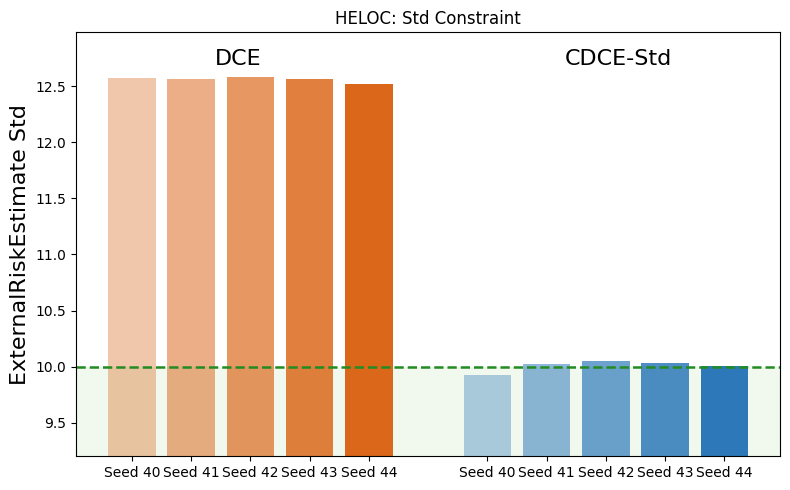

In [10]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ExternalRiskEstimate_col = next(col for col in df.columns if "ExternalRiskEstimate" in col)
    ExternalRiskEstimate_std = round(df[ExternalRiskEstimate_col].dropna().std(), 6)
    result_list.append([sheet, ExternalRiskEstimate_std])

print("=== Result DataFrame (Sheet Name & ExternalRiskEstimate Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "ExternalRiskEstimate_Std"])
print(result_df)

ExternalRiskEstimate_std_mean = round(result_df["ExternalRiskEstimate_Std"].mean(), 6)
ExternalRiskEstimate_std_self_std = round(result_df["ExternalRiskEstimate_Std"].std(), 6)

print("\n=== Overall Statistics of ExternalRiskEstimate Stds ===")
print(f"Mean of 5 ExternalRiskEstimate Stds: {ExternalRiskEstimate_std_mean}")
print(f"Std of 5 ExternalRiskEstimate Stds: {ExternalRiskEstimate_std_self_std}")

baseline_stds = result_df["ExternalRiskEstimate_Std"].tolist()
baseline_std_mean = ExternalRiskEstimate_std_mean

file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ExternalRiskEstimate_col = next(col for col in df.columns if "ExternalRiskEstimate" in col)
    ExternalRiskEstimate_std = round(df[ExternalRiskEstimate_col].dropna().std(), 6)
    result_list.append([sheet, ExternalRiskEstimate_std])

print("=== Result DataFrame (Sheet Name & ExternalRiskEstimate Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "ExternalRiskEstimate_Std"])
print(result_df)

ExternalRiskEstimate_std_mean = round(result_df["ExternalRiskEstimate_Std"].mean(), 6)
ExternalRiskEstimate_std_self_std = round(result_df["ExternalRiskEstimate_Std"].std(), 6)

print("\n=== Overall Statistics of ExternalRiskEstimate Stds ===")
print(f"Mean of 5 ExternalRiskEstimate Stds: {ExternalRiskEstimate_std_mean}")
print(f"Std of 5 ExternalRiskEstimate Stds: {ExternalRiskEstimate_std_self_std}")

stdconstraint_stds = result_df["ExternalRiskEstimate_Std"].tolist()
stdconstraint_std_mean = ExternalRiskEstimate_std_mean

print(baseline_stds)
print(stdconstraint_stds)

x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_stds):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(stdconstraint_stds):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_upper = 10
ax.axhspan(0, target_upper, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_upper, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

y_max = max(max(baseline_stds), max(stdconstraint_stds))
ax.set_ylim(min(9.2, min(min(baseline_stds), min(stdconstraint_stds)) - 0.2), y_max + 0.4)

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Std",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.set_ylabel("ExternalRiskEstimate Std",fontsize=16)
ax.set_title(f"{dataset_name}: Std Constraint")
plt.tight_layout()
plt.show()

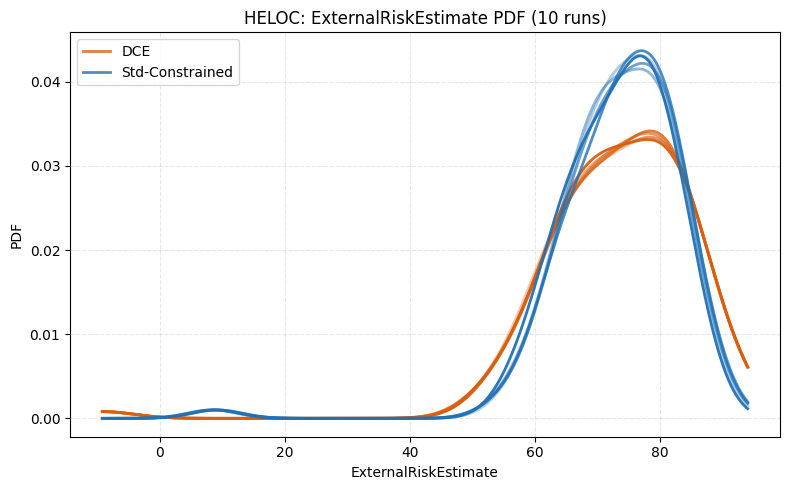

In [11]:
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# ===================== Keep the same colors and alphas =====================
# Reuse your existing baseline_color, constrained_color, and alphas

# ===================== Read DCE data =====================
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

baseline_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ExternalRiskEstimate_col = next(col for col in df.columns if "ExternalRiskEstimate" in col)
    baseline_data.append(df[ExternalRiskEstimate_col].dropna().values)

# ===================== Read StdConstraint data =====================
file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

stdconstraint_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    ExternalRiskEstimate_col = next(col for col in df.columns if "ExternalRiskEstimate" in col)
    stdconstraint_data.append(df[ExternalRiskEstimate_col].dropna().values)

# ===================== Shared x range =====================
all_values = np.concatenate(baseline_data + stdconstraint_data)
x_grid = np.linspace(all_values.min(), all_values.max(), 500)

# ===================== Plot PDFs =====================
fig, ax = plt.subplots(figsize=(8, 5))

for i, values in enumerate(baseline_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=baseline_color, alpha=alphas[i], linewidth=2)

for i, values in enumerate(stdconstraint_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=constrained_color, alpha=alphas[i], linewidth=2)

legend_elements = [
    Line2D([0], [0], color=baseline_color, lw=2, alpha=0.8, label="DCE"),
    Line2D([0], [0], color=constrained_color, lw=2, alpha=0.8, label="Std-Constrained"),
]
ax.legend(handles=legend_elements)

ax.set_xlabel("ExternalRiskEstimate")
ax.set_ylabel("PDF")
ax.set_title(f"{dataset_name}: ExternalRiskEstimate PDF (10 runs)")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# lsc

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os, random, numpy as np, torch

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)          
    np.random.seed(seed)       
    torch.manual_seed(seed)    
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed=42

target_name = "RiskPerformance"  

seed = 42
set_seed(seed)
df_heloc = pd.read_csv('data/HELOC/heloc_dataset_v1 (1).csv')

df_heloc = df_heloc[df_heloc['MSinceOldestTradeOpen'] != -9]

target = df_heloc[target_name].replace({'Good': 0, 'Bad': 1})
# df_X = df_heloc.iloc[:, 1:].copy()
df_X = df_heloc.drop(columns=[target_name]).copy()
df_y = target

set_seed(seed)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train)

X_lin_train = X_train[["NumTotalTrades"]].values.reshape(-1, 1)
y_lin_train = X_train["NumSatisfactoryTrades"].values

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train, y_lin_train)

y_pred_train = lin_reg.predict(X_lin_train)
mse_train = mean_squared_error(y_lin_train, y_pred_train)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
print(f"Linear model: NumSatisfactoryTrades = {coef:.4f} * NumTotalTrades + {intercept:.4f}")
print(f"MSE on training data: {mse_train:.4f}")

      ExternalRiskEstimate  MSinceOldestTradeOpen  MSinceMostRecentTradeOpen  \
4891              0.305860               0.754717                   0.032455   
9837              0.108558              -0.389533                  -0.450458   
2721             -0.976601              -0.096136                  -0.450458   
4318             -1.568507               1.654470                  -0.450458   
2307              2.081576               0.666698                  -0.289487   
...                    ...                    ...                        ...   
6226             -1.469856               1.126354                  -0.209001   
5656              1.391020               0.598239                   0.354397   
5864              1.193718               0.441760                   1.883620   
888               0.799115               0.588459                   1.400708   
7777              1.292369              -0.096136                  -0.128516   

      AverageMInFile  NumSatisfactoryTr

In [13]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    NumSatisfactoryTrades_col = next(col for col in df.columns if "NumSatisfactoryTrades" in col)
    NumTotalTrades_col = next(col for col in df.columns if "NumTotalTrades" in col)
    
    df_clean = df[[NumSatisfactoryTrades_col, NumTotalTrades_col]].dropna()
    NumTotalTrades_scaled = (df_clean[NumTotalTrades_col] - mean["NumTotalTrades"]) / std["NumTotalTrades"]
    NumSatisfactoryTrades_scaled = (df_clean[NumSatisfactoryTrades_col] - mean["NumSatisfactoryTrades"]) / std["NumSatisfactoryTrades"]
    
    y_true = NumSatisfactoryTrades_scaled  
    y_pred = 0.4557 * NumTotalTrades_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6) 
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
    Sheet_Name  Model_MSE
0  DCE_Seed_40   0.503581
1  DCE_Seed_41   0.500260
2  DCE_Seed_42   0.499041
3  DCE_Seed_43   0.491162
4  DCE_Seed_44   0.512650

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.501339
Std of 5 Sheet MSEs: 0.007794


In [14]:
file_path = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    NumSatisfactoryTrades_col = next(col for col in df.columns if "NumSatisfactoryTrades" in col)
    NumTotalTrades_col = next(col for col in df.columns if "NumTotalTrades" in col)
    
    df_clean = df[[NumSatisfactoryTrades_col, NumTotalTrades_col]].dropna()
    NumTotalTrades_scaled = (df_clean[NumTotalTrades_col] - mean["NumTotalTrades"]) / std["NumTotalTrades"]
    NumSatisfactoryTrades_scaled = (df_clean[NumSatisfactoryTrades_col] - mean["NumSatisfactoryTrades"]) / std["NumSatisfactoryTrades"]
    
    y_true = NumSatisfactoryTrades_scaled  
    y_pred = 0.4557 * NumTotalTrades_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6)  
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
               Sheet_Name  Model_MSE
0  LSC_Constraint_Seed_40   0.324121
1  LSC_Constraint_Seed_41   0.304591
2  LSC_Constraint_Seed_42   0.321440
3  LSC_Constraint_Seed_43   0.320009
4  LSC_Constraint_Seed_44   0.322119

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.318456
Std of 5 Sheet MSEs: 0.007891


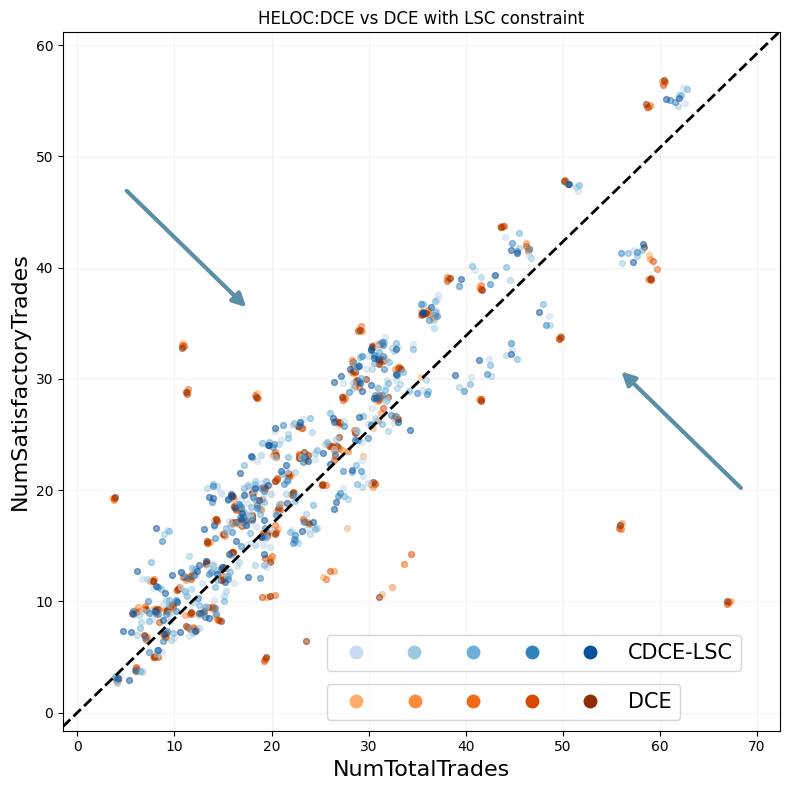

In [15]:
from matplotlib.lines import Line2D

file_path_dce = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
file_path_lsc = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl_dce = pd.ExcelFile(file_path_dce, engine="openpyxl")
xl_lsc = pd.ExcelFile(file_path_lsc, engine="openpyxl")

target_sheets_dce = xl_dce.sheet_names[:5]
target_sheets_lsc = xl_lsc.sheet_names[:5]

color_list_dce = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]
color_list_lsc = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

fig, ax = plt.subplots(figsize=(8, 8))

all_x = []
all_y = []

# DCE: orange
for i, sheet in enumerate(target_sheets_dce):
    df = pd.read_excel(file_path_dce, sheet_name=sheet, engine="openpyxl")
    x_col = "NumTotalTrades"
    y_col = "NumSatisfactoryTrades"

    df_clean = df[[x_col, y_col]].dropna()
    x = df_clean[x_col].to_numpy()
    y = df_clean[y_col].to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_dce[i],
        label=sheet.replace("DCE_", "DCE ")
    )

# LSC: blue
for i, sheet in enumerate(target_sheets_lsc):
    df = pd.read_excel(file_path_lsc, sheet_name=sheet, engine="openpyxl")
    x_col = "NumTotalTrades"
    y_col = "NumSatisfactoryTrades"

    df_clean = df[[x_col, y_col]].dropna()
    x = df_clean[x_col].to_numpy()
    y = df_clean[y_col].to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_lsc[i],
        label=sheet.replace("LSC_", "LSC ")
    )

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

x_range = x_max - x_min
y_range = y_max - y_min

x_left = x_min - 0.08 * x_range
x_right = x_max + 0.08 * x_range
y_low = y_min - 0.08 * y_range
y_high = y_max + 0.08 * y_range

ax.set_xlim(x_left, x_right)
ax.set_ylim(y_low, y_high)

line_x = np.linspace(x_left, x_right, 300)
line_y = 0.8464 * line_x + 0.0000
ax.plot(
    line_x,
    line_y,
    linestyle="--",
    linewidth=2,
    color="black"
)

ax.set_xlabel("NumTotalTrades", fontsize=16)
ax.set_ylabel("NumSatisfactoryTrades", fontsize=16)
ax.set_title(f"{dataset_name}:DCE vs DCE with LSC constraint")
ax.grid(alpha=0.15)

h1 = [Line2D([],[], marker='o', color='w', markerfacecolor=c, markersize=11) for c in color_list_lsc]


h1 = [Line2D([], [], marker='o', color='w', markerfacecolor=c, markersize=11) 
      for c in color_list_lsc]

leg1 = plt.legend(
    handles=h1, 
    labels=["", "", "", "", "CDCE-LSC"], 
    loc="lower right", 
    bbox_to_anchor=(0.96, 0.07), 
    ncol=5, 
    frameon=True, 
    fontsize=15,
    columnspacing=0.01
)
plt.gca().add_artist(leg1)


h2 = [Line2D([], [], marker='o', color='w', markerfacecolor=c, markersize=11) 
      for c in color_list_dce]

leg2 = plt.legend(
    handles=h2, 
    labels=["", "", "", "", "DCE"], 
    loc="lower right", 
    bbox_to_anchor=(0.875, 0.0), 
    ncol=5, 
    frameon=True, 
    fontsize=15,
    columnspacing=0.01
)

ax.annotate(
    "",
    xy=(x_left + 0.3 * x_range, y_low + 0.7 * y_range),
    xytext=(x_left + 0.1 * x_range, y_low + 0.9 * y_range),
    arrowprops=dict(
        arrowstyle="-|>",     
        linewidth=3,          
        color="#5B8FA8",      
        mutation_scale=20     
    )
)

ax.annotate(
    "",
    xy=(x_left + 0.9 * x_range, y_low + 0.6* y_range),
    xytext=(x_left + 1.1 * x_range, y_low + 0.4 * y_range),
    arrowprops=dict(
        arrowstyle="-|>",     
        linewidth=3,          
        color="#5B8FA8",      
        mutation_scale=20     
    )
)


plt.tight_layout()
plt.show()

# fsd

In [16]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch
X_fact= pd.read_csv(os.path.join("HELOC",'HELOC_explained_samples.csv'))
# X_cf= pd.read_csv("cardio_counterfactual.csv")  
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_MSinceMostRecentDelq  = X_fact["NetFractionInstallBurden"]
    cf_MSinceMostRecentDelq = X_cf["NetFractionInstallBurden"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_MSinceMostRecentDelq , cf_MSinceMostRecentDelq ,
        direction=-1   
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1) 

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")


=== Result DataFrame (Sheet Name & Violation Count) ===
    Sheet_Name  Violation_Count
0  DCE_Seed_40               29
1  DCE_Seed_41               40
2  DCE_Seed_42               28
3  DCE_Seed_43               39
4  DCE_Seed_44               32

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 33.600000
Std of 5 Sheet Violation Counts : 5.594640


In [17]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch

X_fact= pd.read_csv(os.path.join("HELOC",'HELOC_explained_samples.csv'))
# X_cf= pd.read_csv("cardio_counterfactual.csv")  

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint_NetFractionInstallBurden_0.005.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_MSinceMostRecentDelq = X_fact["NetFractionInstallBurden"]
    cf_MSinceMostRecentDelq = X_cf["NetFractionInstallBurden"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_MSinceMostRecentDelq, cf_MSinceMostRecentDelq,
        direction=-1  
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1)  

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")


=== Result DataFrame (Sheet Name & Violation Count) ===
               Sheet_Name  Violation_Count
0  FSD_Constraint_Seed_40               11
1  FSD_Constraint_Seed_41               36
2  FSD_Constraint_Seed_42               13
3  FSD_Constraint_Seed_43               23
4  FSD_Constraint_Seed_44                7

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 18.000000
Std of 5 Sheet Violation Counts : 11.661904


[ -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.
  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.
  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  -8.  19.  25.  26.  29.
  31.  32.  38.  38.  44.  45.  49.  50.  50.  51.  56.  56.  59.  60.
  61.  62.  64.  65.  65.  66.  68.  68.  68.  69.  70.  71.  71.  73.
  74.  74.  74.  74.  75.  77.  77.  77.  78.  78.  79.  80.  80.  81.
  84.  84.  85.  85.  89.  90.  93.  94.  94.  96.  96.  97.  98.  98.
  99. 100.]


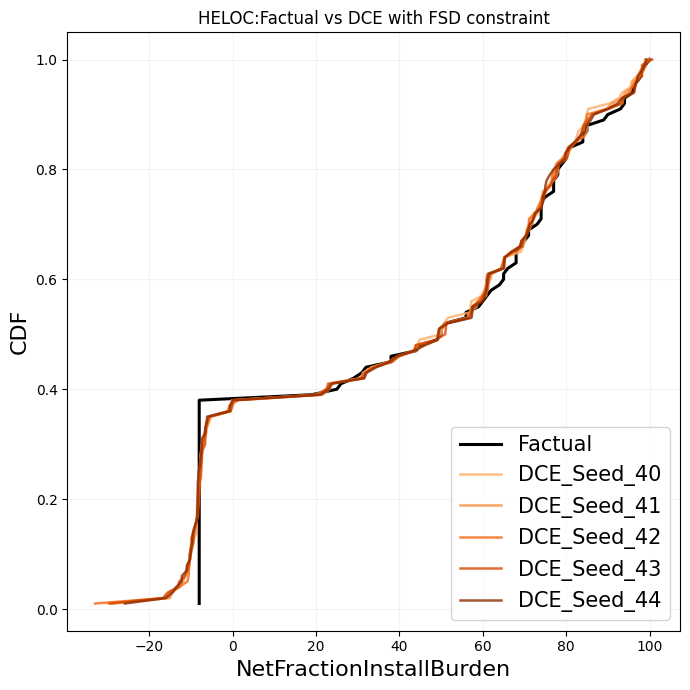

In [18]:
import matplotlib.pyplot as plt
X_fact= pd.read_csv(os.path.join("HELOC",'HELOC_explained_samples.csv'))

fact_weight = X_fact["NetFractionInstallBurden"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
print(fact_weight_sorted)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

orange_colors = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):

    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["NetFractionInstallBurden"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    seed_label = sheet_name

    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=orange_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=seed_label
    )

plt.xlabel("NetFractionInstallBurden", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()

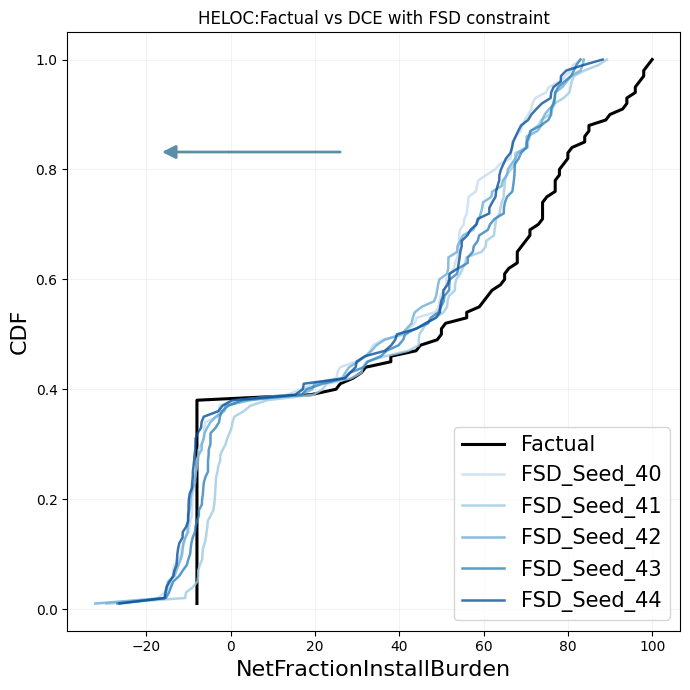

In [19]:
X_fact= pd.read_csv(os.path.join("HELOC",'HELOC_explained_samples.csv'))

fact_weight = X_fact["NetFractionInstallBurden"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint_NetFractionInstallBurden_0.005.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

blue_colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):
    # print("sheet_name:", sheet_name, "| type:", type(sheet_name))
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["NetFractionInstallBurden"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    # print(cf_weight_sorted)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    seed_label = sheet_name.replace("_Constraint", "")
    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=blue_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=seed_label
    )

ax = plt.gca()

ax.annotate(
    '',
    # xy=(0.8, 0.8),      
    # xytext=(0.8, 0.4),  
    xy=(0.15, 0.80),
    xytext=(0.45, 0.80),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=6,
        mutation_scale=20,
        color="#5B8FA8",
        lw=2
    )
)


plt.xlabel("NetFractionInstallBurden", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()